In [2]:
#IMPORTS AND CONFIGS
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


%matplotlib inline
warnings.filterwarnings("ignore")

#---Paths
PROJECT_ROOT=Path.cwd().parent
DATA_PATH = PROJECT_ROOT/"data"/"raw"/"WA_Fn-UseC_-HR-Employee-Attrition.csv"
FIGURES_DIR = PROJECT_ROOT/"reports"/"figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

#Plot Style
plt.rcParams.update({
    "figure.dpi"        : 120,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "axes.grid.axis"    : "y",
    "grid.alpha"        : 0.3,
    "font.size"         : 11,
})

PALETTE = {"Yes":"#E24B4A","No":"#1D9E75"}
BLUE = "#185FA5"

#Sanity Check
print(f"Project Root : {PROJECT_ROOT}")
print(f"Data Path :  {DATA_PATH}")
print(f"Figures dir : {FIGURES_DIR}")
print(f"Data file exists : {DATA_PATH.exists()}")

Project Root : d:\hr-attrition-predictor
Data Path :  d:\hr-attrition-predictor\data\raw\WA_Fn-UseC_-HR-Employee-Attrition.csv
Figures dir : d:\hr-attrition-predictor\reports\figures
Data file exists : True


In [3]:
#Helper Function

def save(fig, filename):
    path=FIGURES_DIR/filename
    fig.savefig(path,bbox_inches="tight")
    print(f" ✓ Saved -> {path}")

def section(title):
    print(f"\n{'=' * 55}")
    print(f"   {title}")
    print(f"{'=' * 55}")

In [4]:
#Section 1 -- Load & Inspect the Data

section("SECTION 1 - Load & Inspect the Data")

df=pd.read_csv(DATA_PATH)
print(f"\n Rows :{df.shape[0]:,}")
print(f" Columns : {df.shape[1]}")
print(f"\n Column names:\n {list(df.columns)}")


   SECTION 1 - Load & Inspect the Data

 Rows :1,470
 Columns : 35

 Column names:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [5]:
print("First 5 rows: \n")
df.head()

First 5 rows: 



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
print("Data Types: \n")
print(df.dtypes.to_string())
print("\nSummary statistics: \n")
df.describe().round(2)

Data Types: 

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalW

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [7]:
#Drop useless columns

#Columns with only one unique value carry zero information for ML 
useless = [c for c in df.columns if df[c].nunique()<=1]
print(f"Single-value columns (dropping): {useless}")
df.drop(columns=useless, inplace=True)

if "EmployeeNumber" in df.columns:
    df.drop(columns=["EmployeeNumber"], inplace=True)

print(f"\nDataset shape after cleanup: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Single-value columns (dropping): ['EmployeeCount', 'Over18', 'StandardHours']

Dataset shape after cleanup: (1470, 31)
Remaining columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [8]:
#Section 2 - Missing Values Check

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
bad_cols = missing[missing > 0]

if bad_cols.empty:
    print("\n ✓ No missing values. IBM HR is a clean synthetic dataset.")
else:
    result=pd.DataFrame({
        "Missing Count" : bad_cols,
        "Missing %" : missing_pct[bad_cols.index]
    })
    print(result)


 ✓ No missing values. IBM HR is a clean synthetic dataset.


In [9]:
counts = df["Attrition"].value_counts()
pcts = df["Attrition"].value_counts(normalize=True) * 100

print("\n Attrition breakdown: ")
for label in counts.index:
    bar= "█" * int(pcts[label] / 2)
    print(f" {label:3s} {counts[label]:4d} ({pcts[label]:.1f}%) {bar}")

print(f"""
  ─────────────────────────────────────────────────
  Key observation:
  • Only {pcts['Yes']:.1f}% of employees left → dataset is IMBALANCED
  • A naive model saying "nobody leaves" = {pcts['No']:.1f}% accurate (misleading!)
  ─────────────────────────────────────────────────
""")


 Attrition breakdown: 
 No  1233 (83.9%) █████████████████████████████████████████
 Yes  237 (16.1%) ████████

  ─────────────────────────────────────────────────
  Key observation:
  • Only 16.1% of employees left → dataset is IMBALANCED
  • A naive model saying "nobody leaves" = 83.9% accurate (misleading!)
  ─────────────────────────────────────────────────



 ✓ Saved -> d:\hr-attrition-predictor\reports\figures\01_attrition_distribution.png


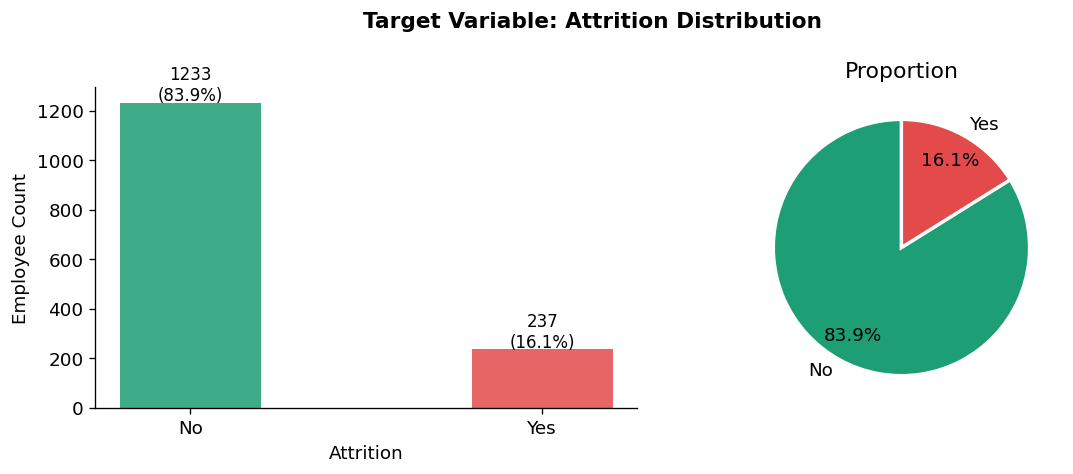

In [10]:
#Section 3 -- Attrition Chart

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Target Variable: Attrition Distribution", fontsize=13, fontweight="bold")

# Bar chart
colors = [PALETTE[k] for k in counts.index]
axes[0].bar(counts.index, counts.values, color=colors, width=0.4, alpha=0.85)
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Employee Count")
axes[0].grid(False)
for i, (k, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v + 8, f"{v}\n({pcts[k]:.1f}%)", ha="center", fontsize=10)

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proportion")

plt.tight_layout()
save(fig, "01_attrition_distribution.png")
plt.show()

In [12]:
#Section 4 - Numeric Feature Distribution - Stats

numeric_cols=df.select_dtypes(include=np.number).columns.tolist()
print(f"\n Numeric columns ({len(numeric_cols)}):\n {numeric_cols}")
print()
df[numeric_cols].describe().round(1)


 Numeric columns (23):
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']



,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,...,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,36.9,802.5,9.2,2.9,2.7,65.9,2.7,2.1,2.7,6502.9,...,3.2,2.7,0.8,11.3,2.8,2.8,7.0,4.2,2.2,4.1
std,9.1,403.5,8.1,1.0,1.1,20.3,0.7,1.1,1.1,4708.0,...,0.4,1.1,0.9,7.8,1.3,0.7,6.1,3.6,3.2,3.6
min,18.0,102.0,1.0,1.0,1.0,30.0,1.0,1.0,1.0,1009.0,...,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,30.0,465.0,2.0,2.0,2.0,48.0,2.0,1.0,2.0,2911.0,...,3.0,2.0,0.0,6.0,2.0,2.0,3.0,2.0,0.0,2.0
50%,36.0,802.0,7.0,3.0,3.0,66.0,3.0,2.0,3.0,4919.0,...,3.0,3.0,1.0,10.0,3.0,3.0,5.0,3.0,1.0,3.0
75%,43.0,1157.0,14.0,4.0,4.0,83.8,3.0,3.0,4.0,8379.0,...,3.0,4.0,1.0,15.0,3.0,3.0,9.0,7.0,3.0,7.0
max,60.0,1499.0,29.0,5.0,4.0,100.0,4.0,5.0,4.0,19999.0,...,4.0,4.0,3.0,40.0,6.0,4.0,40.0,18.0,15.0,17.0


 ✓ Saved -> d:\hr-attrition-predictor\reports\figures\02_numeric_distributions.png


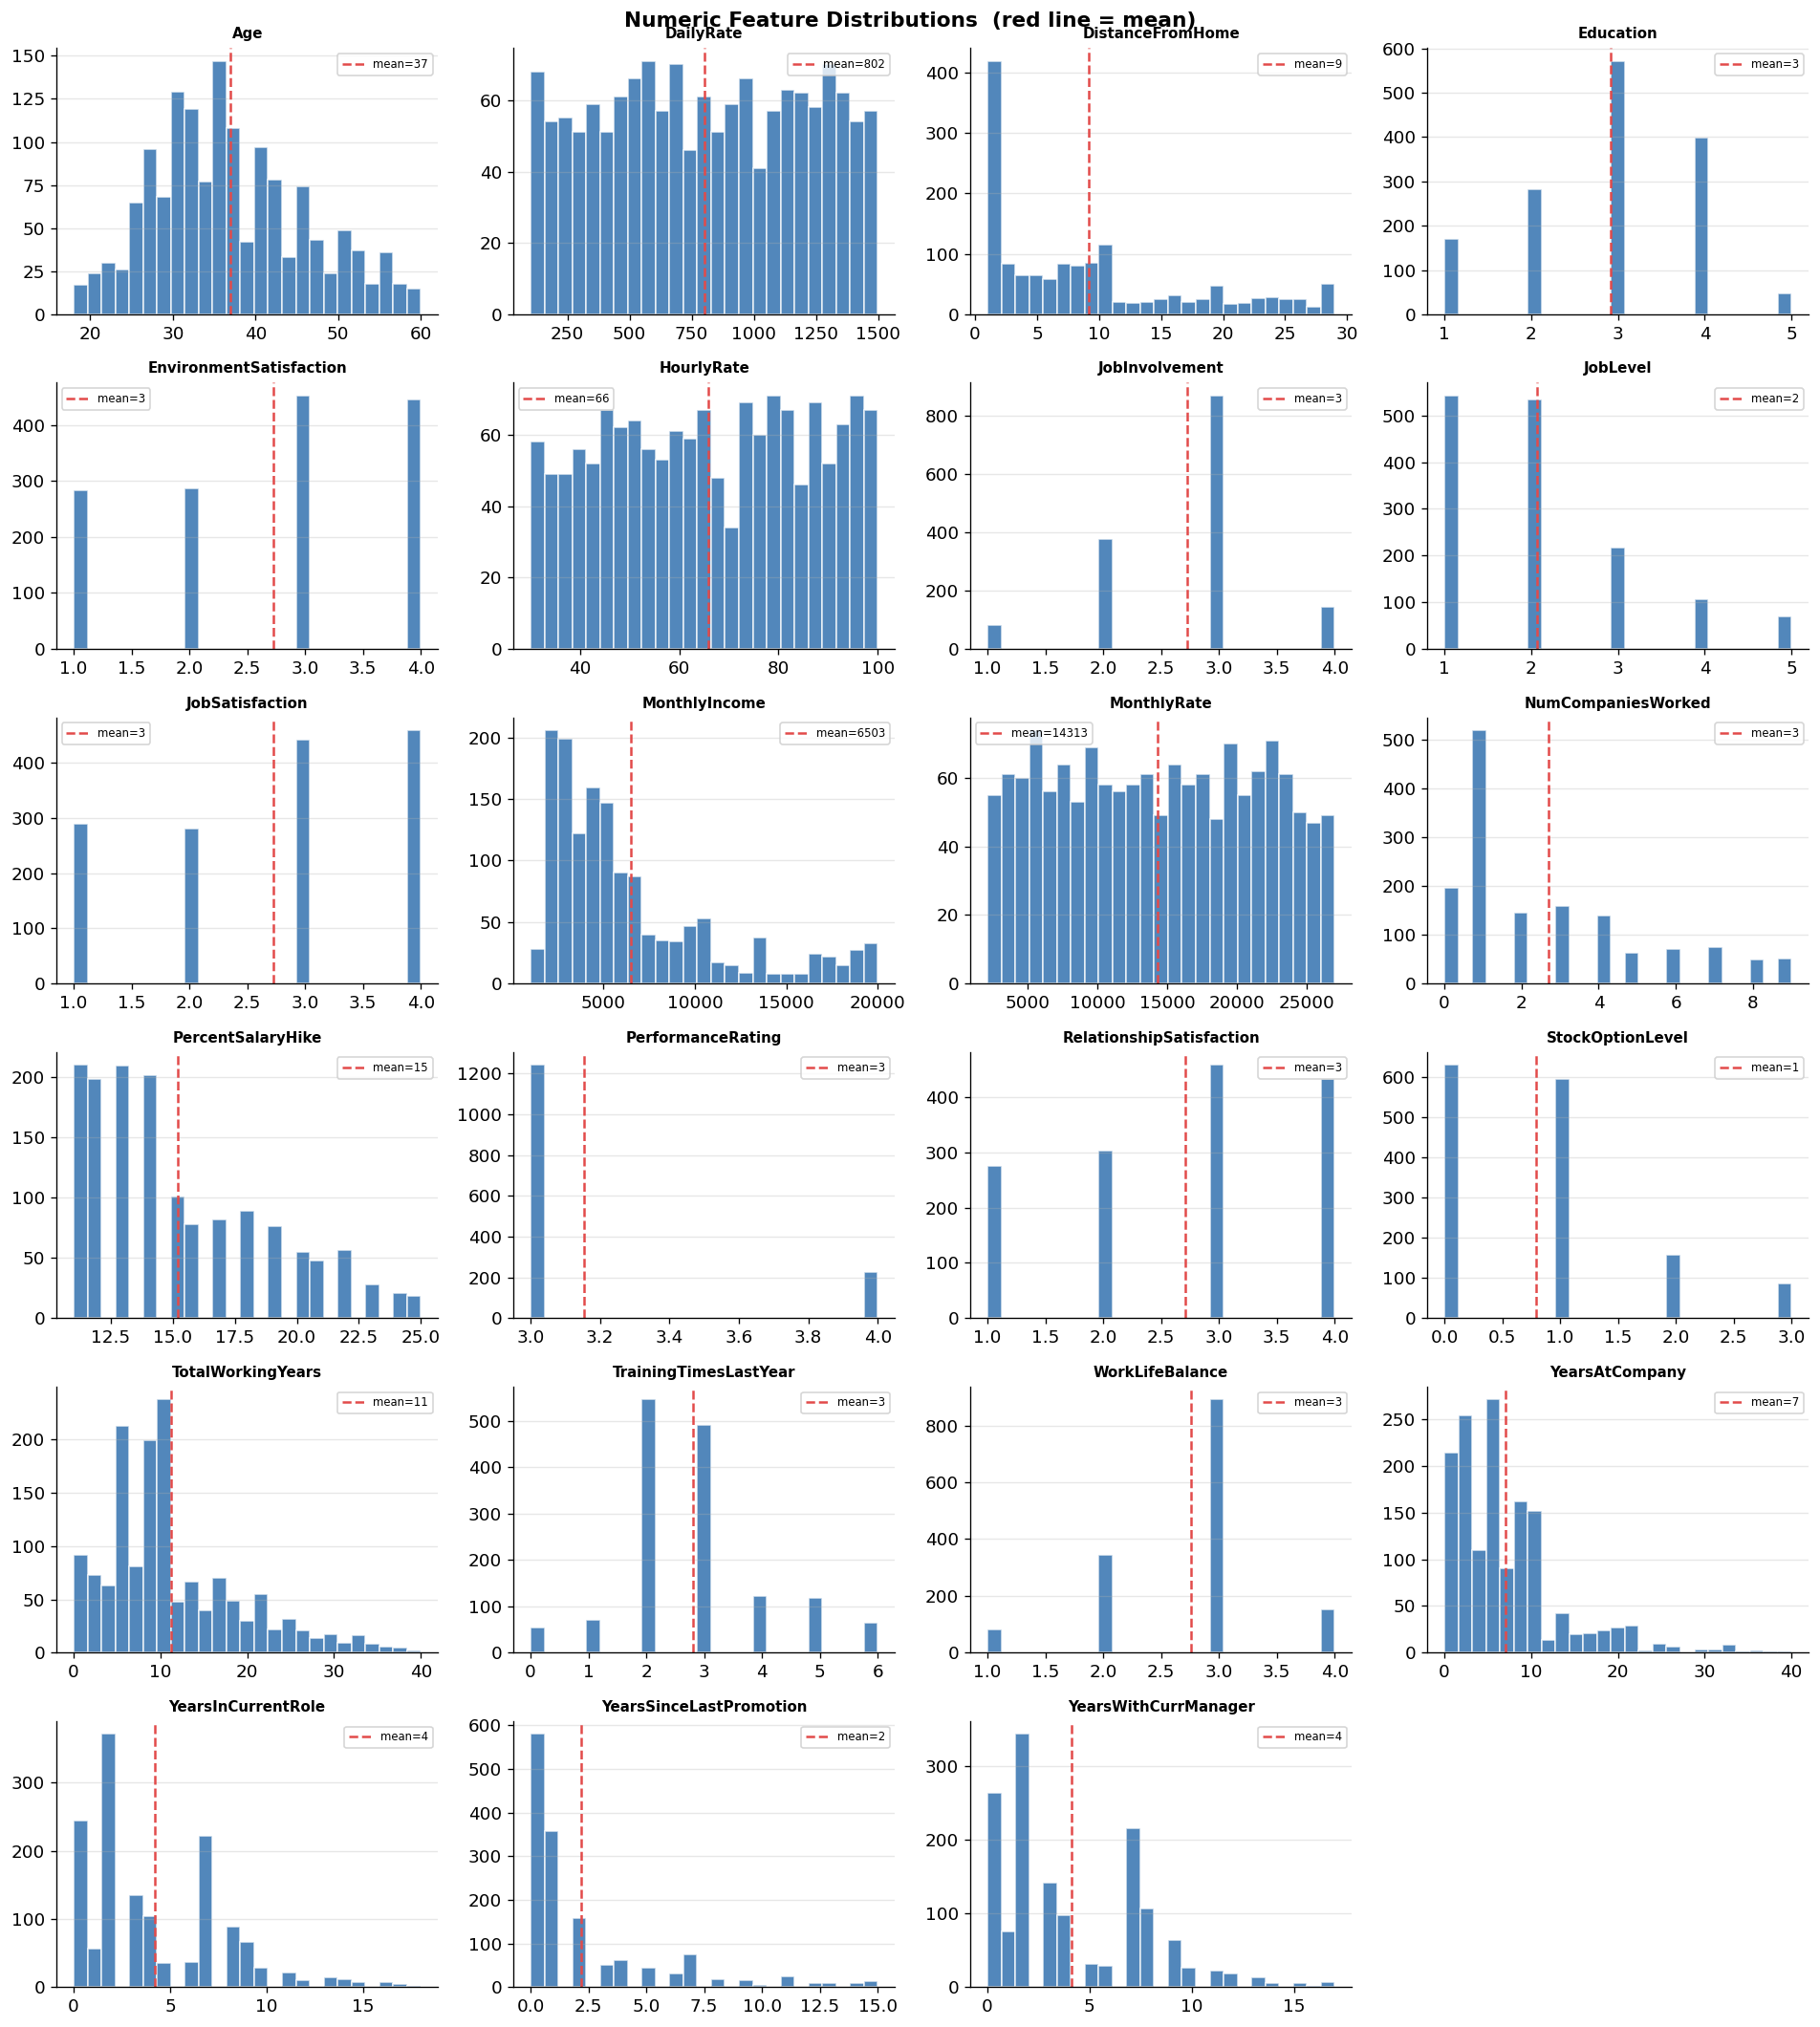

In [13]:
n_cols=4
n_rows=(len(numeric_cols)+n_cols-1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, color=BLUE, alpha=0.75, edgecolor="white")
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].axvline(
        df[col].mean(), color="#E24B4A", linewidth=1.5,
        linestyle="--", label=f"mean={df[col].mean():.0f}"
    )
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Feature Distributions  (red line = mean)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save(fig, "02_numeric_distributions.png")
plt.show()


In [14]:
#Section 5 -- Categorical Features - Stats

cat_cols = [c for c in df.select_dtypes("object").columns if c!= "Attrition"]

print(f"\n Categorical columns ({len(cat_cols)}) : {cat_cols}\n")

for col in cat_cols:
    vc = df[col].value_counts()
    print(f" {col}  ({df[col].nunique()} unique values):")
    for val, cnt in vc.items():
        print(f" {val:35s} {cnt:4d} ({cnt/len(df) * 100:.1f}%)")
    print()


 Categorical columns (7) : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

 BusinessTravel  (3 unique values):
 Travel_Rarely                       1043 (71.0%)
 Travel_Frequently                    277 (18.8%)
 Non-Travel                           150 (10.2%)

 Department  (3 unique values):
 Research & Development               961 (65.4%)
 Sales                                446 (30.3%)
 Human Resources                       63 (4.3%)

 EducationField  (6 unique values):
 Life Sciences                        606 (41.2%)
 Medical                              464 (31.6%)
 Marketing                            159 (10.8%)
 Technical Degree                     132 (9.0%)
 Other                                 82 (5.6%)
 Human Resources                       27 (1.8%)

 Gender  (2 unique values):
 Male                                 882 (60.0%)
 Female                               588 (40.0%)

 JobRole  (9 unique values):
 Sales Ex

 ✓ Saved -> d:\hr-attrition-predictor\reports\figures\03_categorical_distributions.png


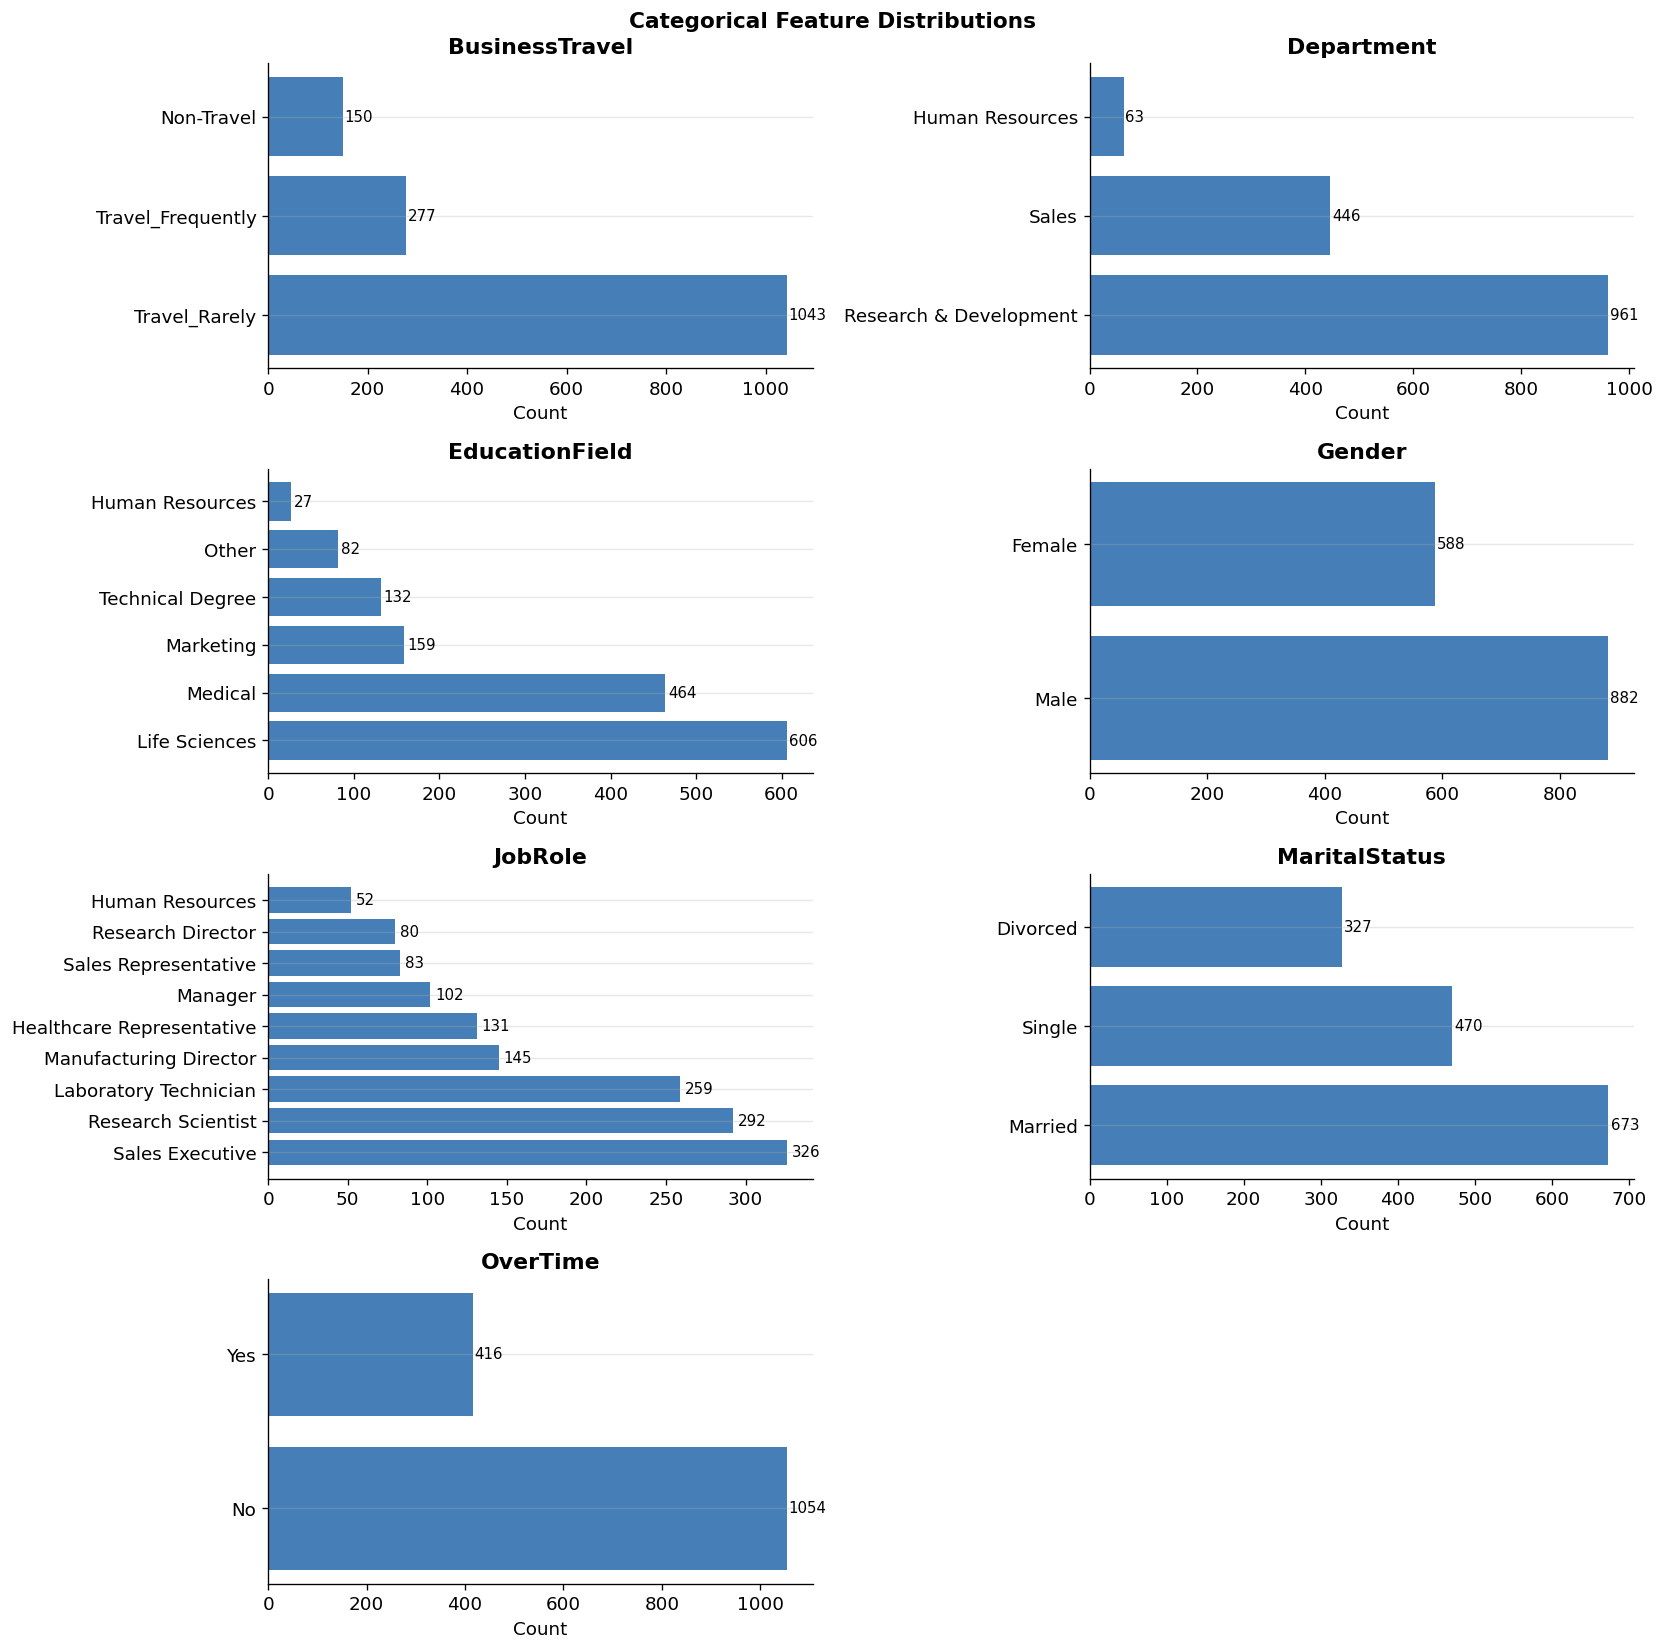

In [22]:
n_cols = 2
n_rows = (len(cat_cols) + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].barh(vc.index, vc.values, color=BLUE, alpha=0.8)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("Count")
    for j, v in enumerate(vc.values):
        axes[i].text(v + 3, j, str(v), va="center", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
save(fig, "03_categorical_distributions.png")
plt.show()

In [23]:
#Section 6 -- Attrition Rate by Categorical Features -- Stats

cat_to_plot  = ["Department", "JobRole", "OverTime",
                "MaritalStatus", "BusinessTravel", "Gender"]
overall_avg  = (df["Attrition"] == "Yes").mean() * 100

print(f"\n  Overall attrition rate: {overall_avg:.1f}%\n")
print(f"  {'Feature':<20}  {'Group':<35}  {'Rate':>6}  {'vs Avg':>8}")
print(f"  {'─'*20}  {'─'*35}  {'─'*6}  {'─'*8}")

for col in cat_to_plot:
    rate = (
        df.groupby(col)["Attrition"]
          .apply(lambda x: (x == "Yes").sum() / len(x) * 100)
          .sort_values(ascending=False)
    )
    for grp, val in rate.items():
        diff   = val - overall_avg
        flag   = " ← HIGH RISK" if val > overall_avg * 1.5 else ""
        sign   = "+" if diff >= 0 else ""
        print(f"  {col:<20}  {str(grp):<35}  {val:>5.1f}%  {sign}{diff:>6.1f}%{flag}")
    print()


  Overall attrition rate: 16.1%

  Feature               Group                                  Rate    vs Avg
  ────────────────────  ───────────────────────────────────  ──────  ────────
  Department            Sales                                 20.6%  +   4.5%
  Department            Human Resources                       19.0%  +   2.9%
  Department            Research & Development                13.8%    -2.3%

  JobRole               Sales Representative                  39.8%  +  23.6% ← HIGH RISK
  JobRole               Laboratory Technician                 23.9%  +   7.8%
  JobRole               Human Resources                       23.1%  +   7.0%
  JobRole               Sales Executive                       17.5%  +   1.4%
  JobRole               Research Scientist                    16.1%    -0.0%
  JobRole               Manufacturing Director                 6.9%    -9.2%
  JobRole               Healthcare Representative              6.9%    -9.3%
  JobRole            

 ✓ Saved -> d:\hr-attrition-predictor\reports\figures\04_attrition_by_category.png


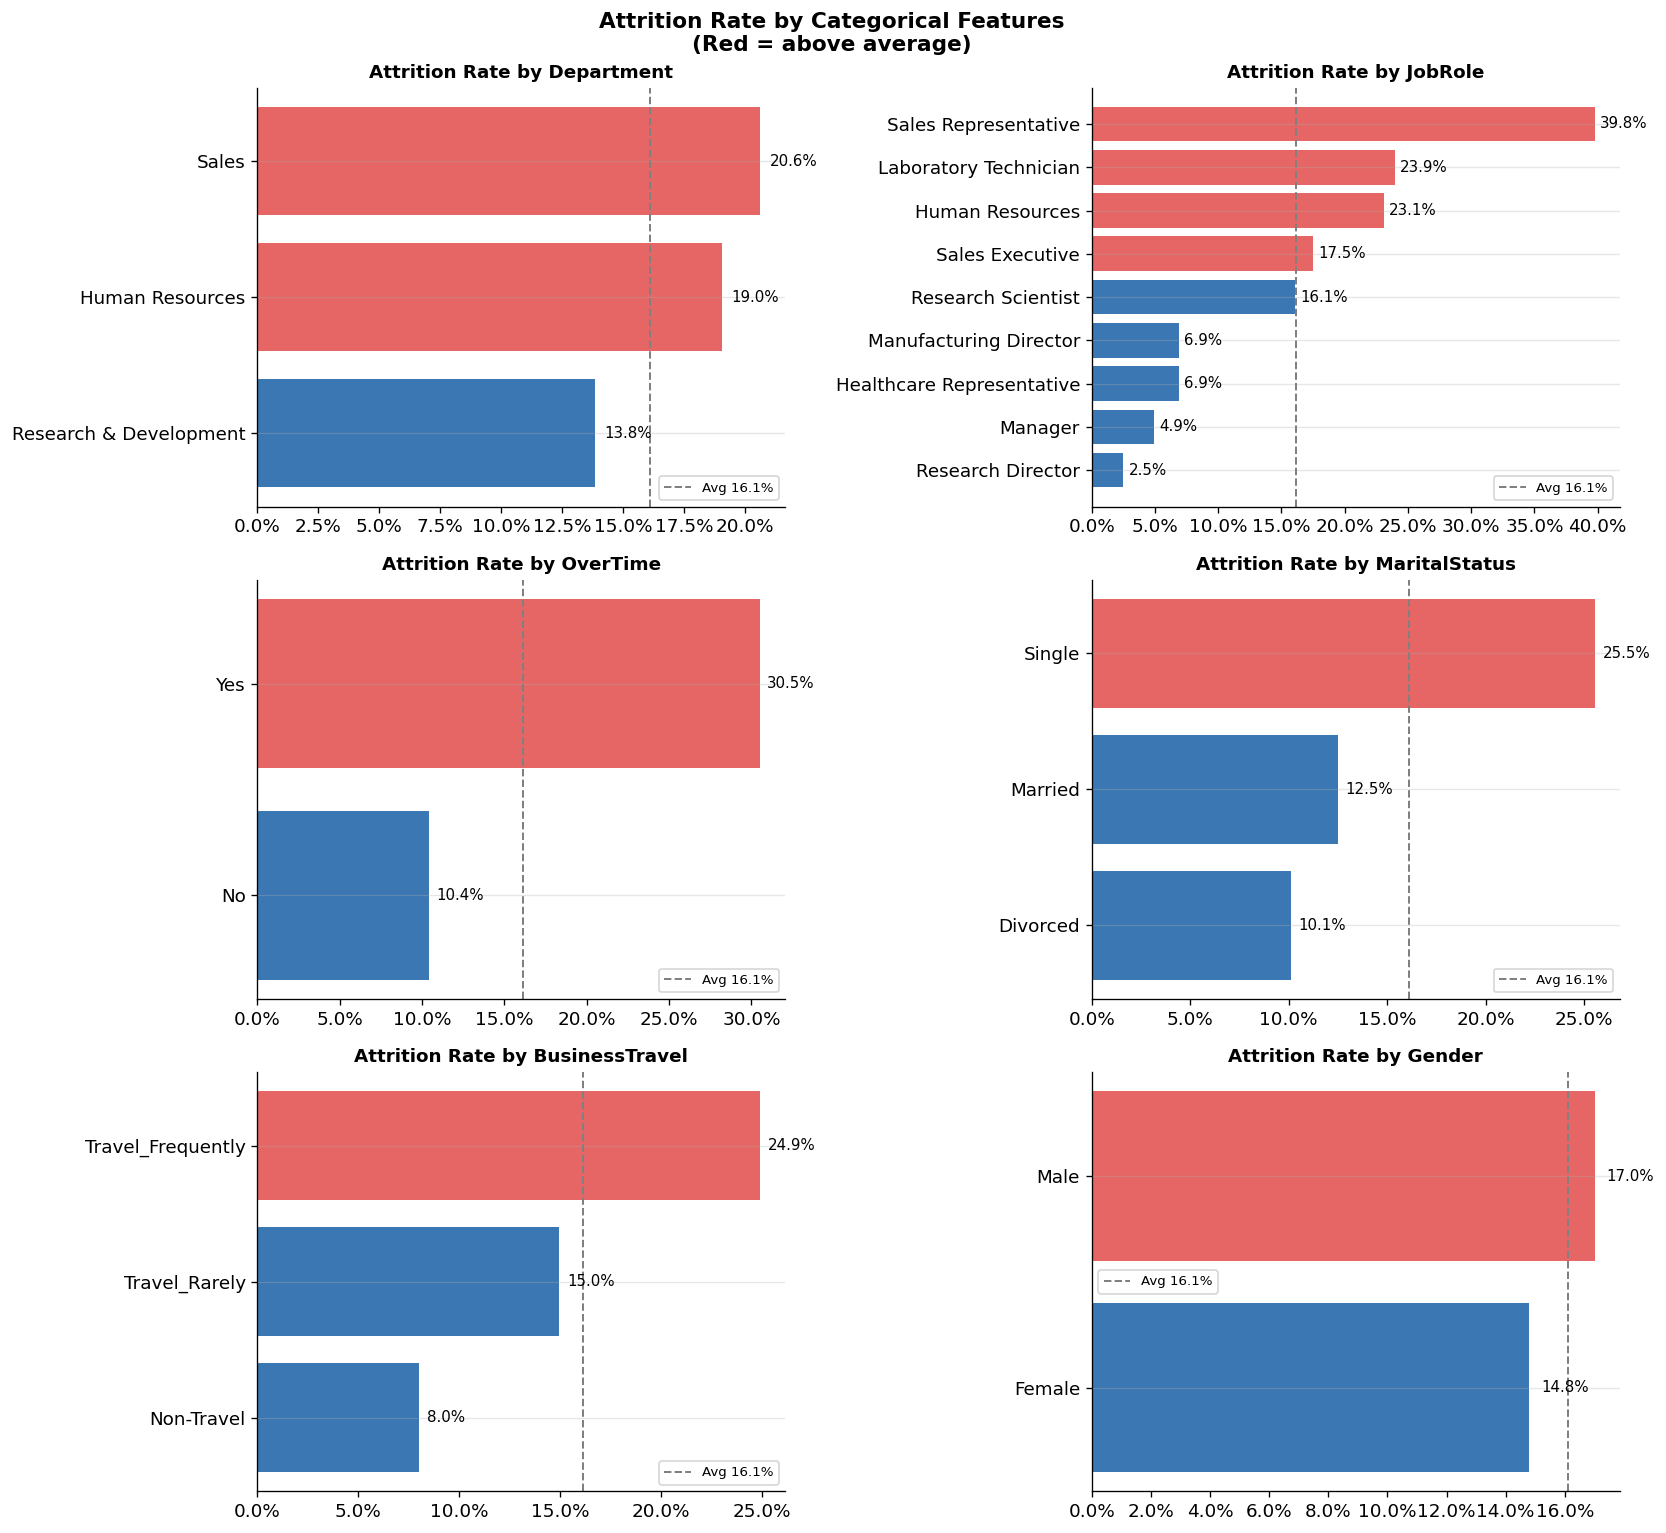

In [24]:
#Section 6 -- Attrition Rate by Category -- Chart 
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot):
    rate = (
        df.groupby(col)["Attrition"]
          .apply(lambda x: (x == "Yes").sum() / len(x) * 100)
          .sort_values(ascending=True)
    )
    bar_colors = ["#E24B4A" if v > overall_avg else BLUE for v in rate.values]

    axes[i].barh(rate.index, rate.values, color=bar_colors, alpha=0.85)
    axes[i].axvline(overall_avg, color="gray", linestyle="--",
                    linewidth=1.2, label=f"Avg {overall_avg:.1f}%")
    axes[i].set_title(f"Attrition Rate by {col}", fontweight="bold", fontsize=11)
    axes[i].xaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].legend(fontsize=8)
    for j, v in enumerate(rate.values):
        axes[i].text(v + 0.4, j, f"{v:.1f}%", va="center", fontsize=9)

fig.suptitle("Attrition Rate by Categorical Features\n(Red = above average)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save(fig, "04_attrition_by_category.png")
plt.show()

In [25]:
#Section 7 -- Key Numeric Features vs Attrition -- Stats

key_numeric = ["Age", "MonthlyIncome", "TotalWorkingYears",
               "YearsAtCompany", "JobSatisfaction", "DistanceFromHome"]

print(f"\n  {'Feature':<25}  {'Left (Yes)':>12}  {'Stayed (No)':>12}  {'Gap':>10}")
print(f"  {'─'*25}  {'─'*12}  {'─'*12}  {'─'*10}")

for col in key_numeric:
    yes_m = df[df["Attrition"] == "Yes"][col].mean()
    no_m  = df[df["Attrition"] == "No"][col].mean()
    diff  = yes_m - no_m
    sign  = "+" if diff > 0 else ""
    print(f"  {col:<25}  {yes_m:>12.2f}  {no_m:>12.2f}  {sign}{diff:>9.2f}")



  Feature                      Left (Yes)   Stayed (No)         Gap
  ─────────────────────────  ────────────  ────────────  ──────────
  Age                               33.61         37.56      -3.95
  MonthlyIncome                   4787.09       6832.74   -2045.65
  TotalWorkingYears                  8.24         11.86      -3.62
  YearsAtCompany                     5.13          7.37      -2.24
  JobSatisfaction                    2.47          2.78      -0.31
  DistanceFromHome                  10.63          8.92  +     1.72


 ✓ Saved -> d:\hr-attrition-predictor\reports\figures\05_numeric_vs_attrition.png


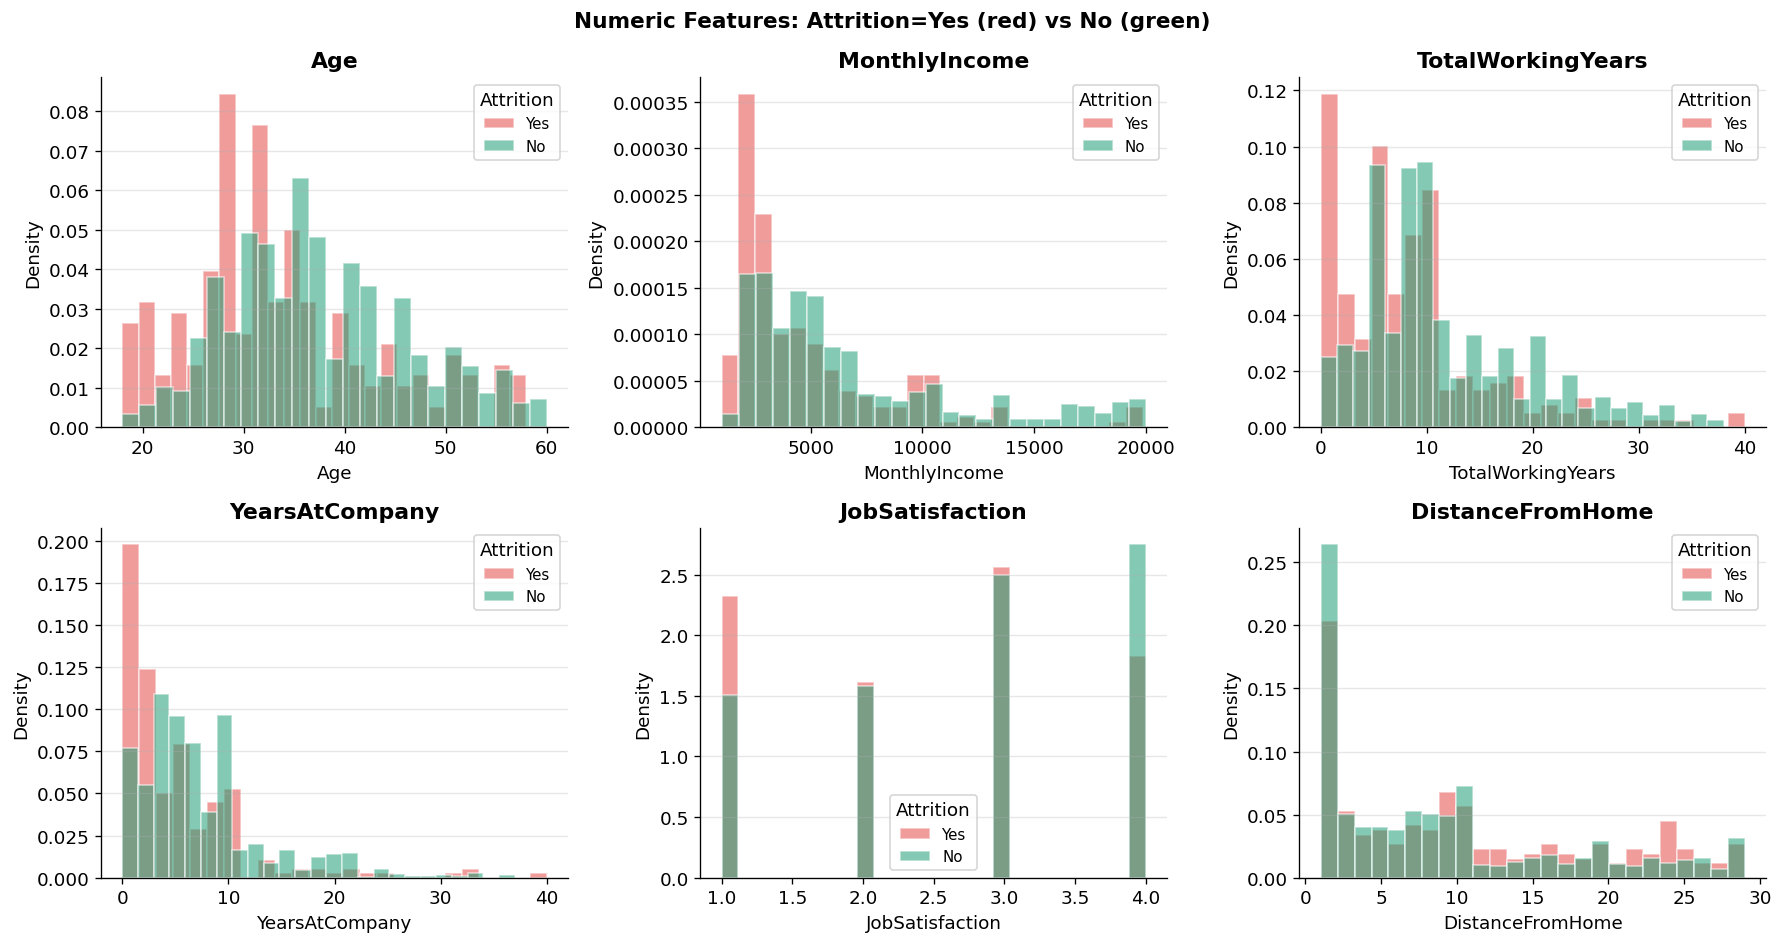

In [26]:
#Section 7-- Numeric vs Attrition -- Overlapping Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    for label, color in PALETTE.items():
        subset = df[df["Attrition"] == label][col]
        axes[i].hist(
            subset, bins=25, alpha=0.55, label=label,
            color=color, edgecolor="white", density=True
        )
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(title="Attrition", fontsize=9)

fig.suptitle("Numeric Features: Attrition=Yes (red) vs No (green)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save(fig, "05_numeric_vs_attrition.png")
plt.show()

 ✓ Saved -> d:\hr-attrition-predictor\reports\figures\06_boxplots_income_age.png


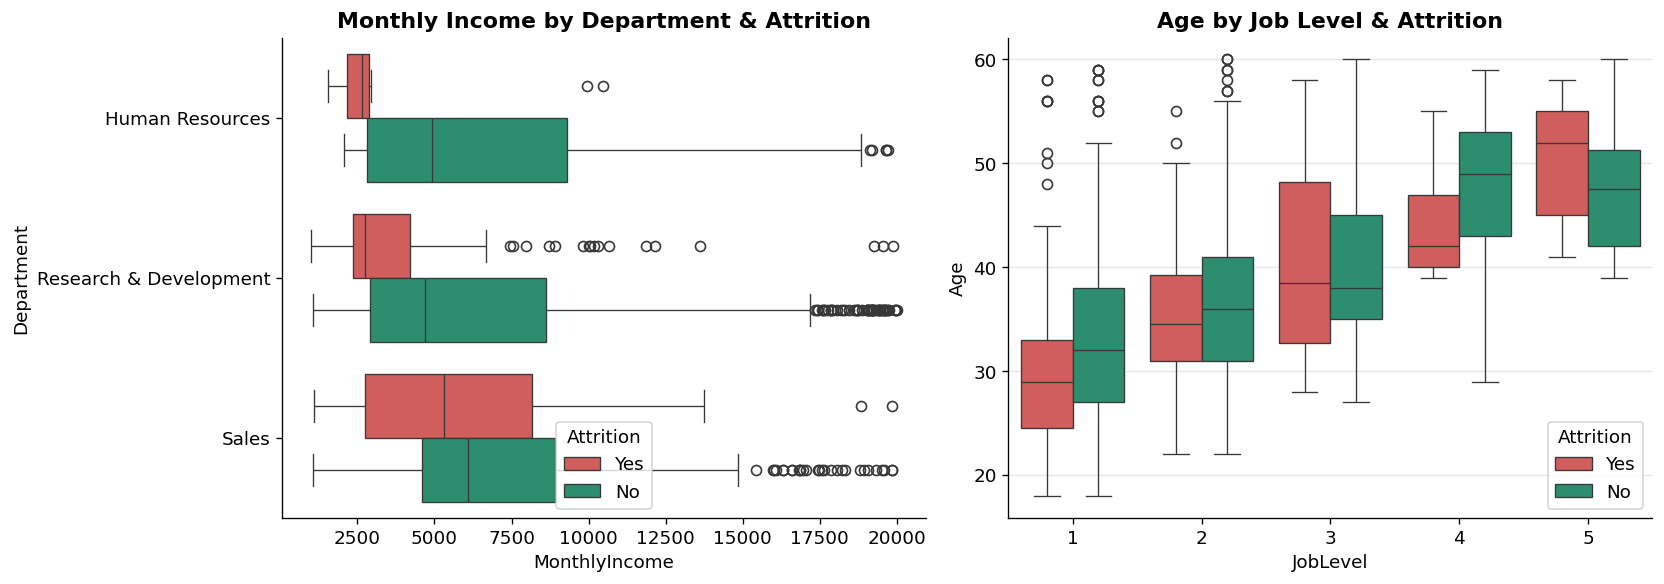

In [27]:
#Section 7 -- Box Plots: Income & Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_order = (df.groupby("Department")["MonthlyIncome"]
                .median().sort_values().index.tolist())

sns.boxplot(
    data=df, x="MonthlyIncome", y="Department",
    hue="Attrition", order=dept_order,
    palette=PALETTE, ax=axes[0], linewidth=0.8
)
axes[0].set_title("Monthly Income by Department & Attrition", fontweight="bold")
axes[0].legend(title="Attrition")

sns.boxplot(
    data=df, x="JobLevel", y="Age",
    hue="Attrition", palette=PALETTE,
    ax=axes[1], linewidth=0.8
)
axes[1].set_title("Age by Job Level & Attrition", fontweight="bold")
axes[1].legend(title="Attrition")

plt.tight_layout()
save(fig, "06_boxplots_income_age.png")
plt.show()


In [28]:
#Section -- Correlation Heatmap --Stats

df_corr              = df.copy()
df_corr["Attrition_bin"] = (df_corr["Attrition"] == "Yes").astype(int)

numeric_for_corr = df_corr.select_dtypes(include=np.number).columns.tolist()
corr             = df_corr[numeric_for_corr].corr()

top10 = (
    corr["Attrition_bin"]
    .drop("Attrition_bin")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("\n  Top 10 features correlated with Attrition:\n")
print(f"  {'Feature':<30}  {'|r|':>6}  {'Direction'}")
print(f"  {'─'*30}  {'─'*6}  {'─'*35}")

for feat, val in top10.items():
    raw = corr.loc[feat, "Attrition_bin"]
    direction = "↑ more = more attrition" if raw > 0 else "↓ less = more attrition"
    print(f"  {feat:<30}  {val:>6.3f}  {direction}")


  Top 10 features correlated with Attrition:

  Feature                            |r|  Direction
  ──────────────────────────────  ──────  ───────────────────────────────────
  TotalWorkingYears                0.171  ↓ less = more attrition
  JobLevel                         0.169  ↓ less = more attrition
  YearsInCurrentRole               0.161  ↓ less = more attrition
  MonthlyIncome                    0.160  ↓ less = more attrition
  Age                              0.159  ↓ less = more attrition
  YearsWithCurrManager             0.156  ↓ less = more attrition
  StockOptionLevel                 0.137  ↓ less = more attrition
  YearsAtCompany                   0.134  ↓ less = more attrition
  JobInvolvement                   0.130  ↓ less = more attrition
  JobSatisfaction                  0.103  ↓ less = more attrition


 ✓ Saved -> d:\hr-attrition-predictor\reports\figures\07_correlation_heatmap.png


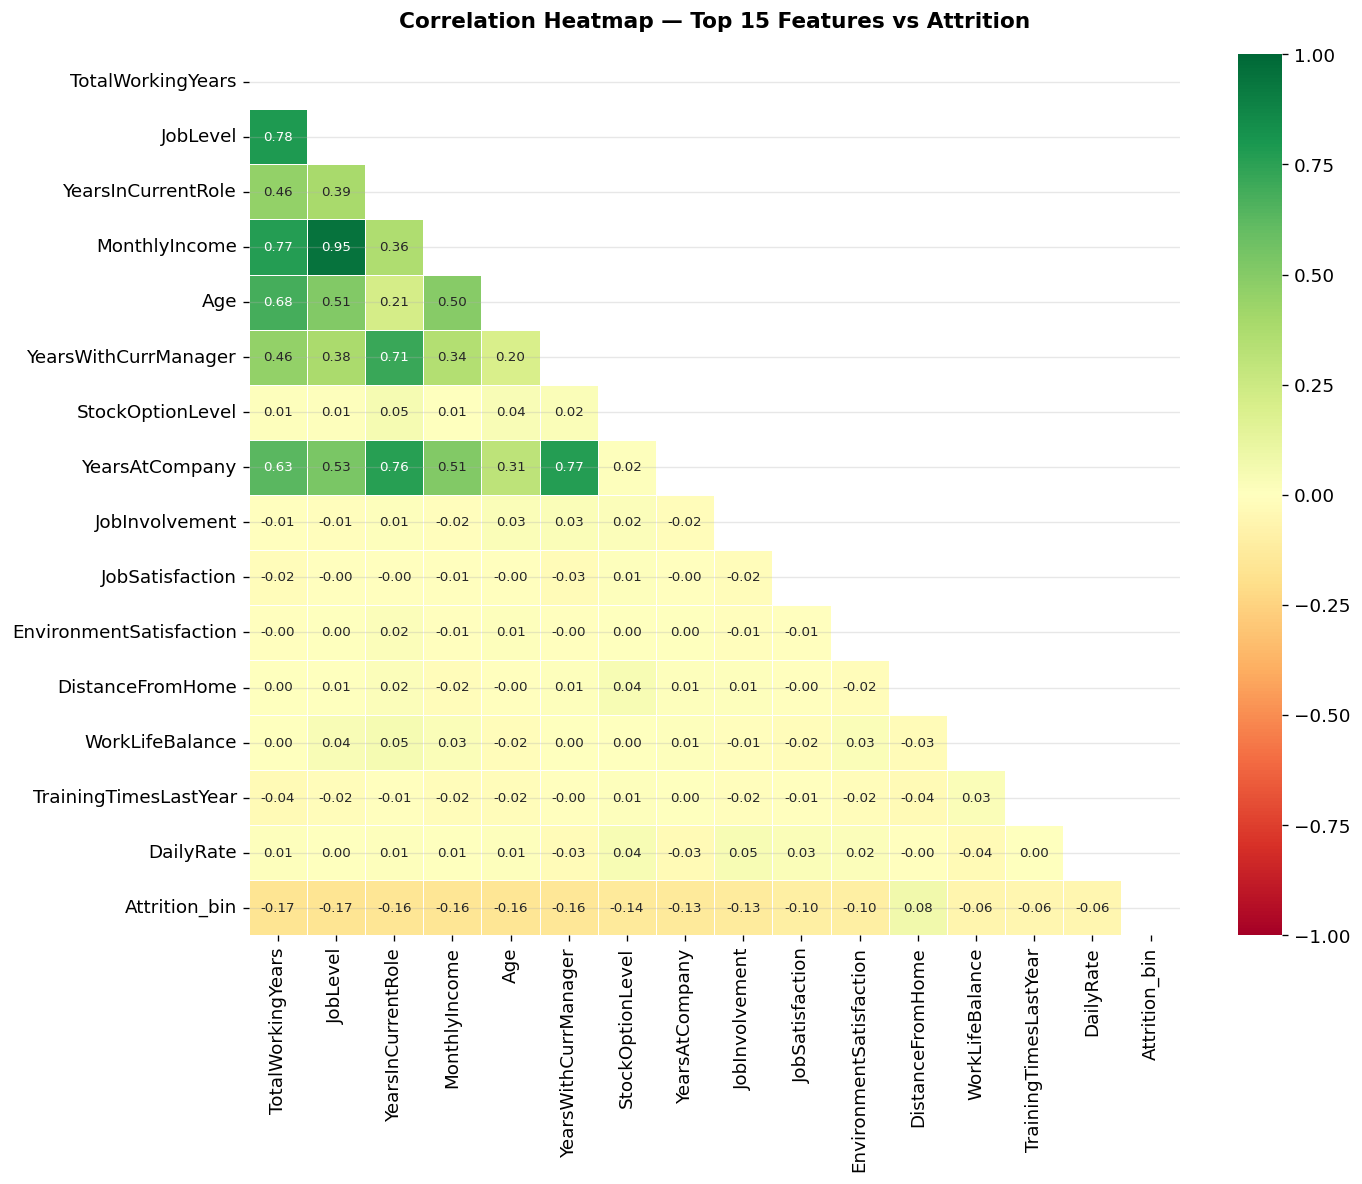

In [29]:
#section 8 --  Correlation HeatMap -- Chart

top15 = (
    corr["Attrition_bin"]
    .drop("Attrition_bin")
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)
top15.append("Attrition_bin")
sub_corr = corr.loc[top15, top15]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(sub_corr, dtype=bool))   # show lower triangle only

sns.heatmap(
    sub_corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={"size": 8},
    ax=ax,
)
ax.set_title("Correlation Heatmap — Top 15 Features vs Attrition",
             fontsize=13, fontweight="bold", pad=16)
plt.tight_layout()
save(fig, "07_correlation_heatmap.png")
plt.show()

In [30]:
#Section 9 -- Overtime Deep Dive -- Stats

ot_overall = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

ot_dept = (
    df.groupby(["OverTime", "Department"])["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .unstack()
      .round(1)
)

print("\n  Overall attrition rate by OverTime status:")
for ot, rate in ot_overall.items():
    print(f"    {ot:3s}  →  {rate:.1f}%")

print(f"\n  Employees doing OverTime leave at "
      f"{ot_overall['Yes'] / ot_overall['No']:.1f}× the rate of those who don't.\n")

print("  Attrition rate (%) by OverTime × Department:")
print(ot_dept.to_string())


  Overall attrition rate by OverTime status:
    No   →  10.4%
    Yes  →  30.5%

  Employees doing OverTime leave at 2.9× the rate of those who don't.

  Attrition rate (%) by OverTime × Department:
Department  Human Resources  Research & Development  Sales
OverTime                                                  
No                     15.2                     8.6   13.8
Yes                    29.4                    27.3   37.5


 ✓ Saved -> d:\hr-attrition-predictor\reports\figures\08_overtime_analysis.png


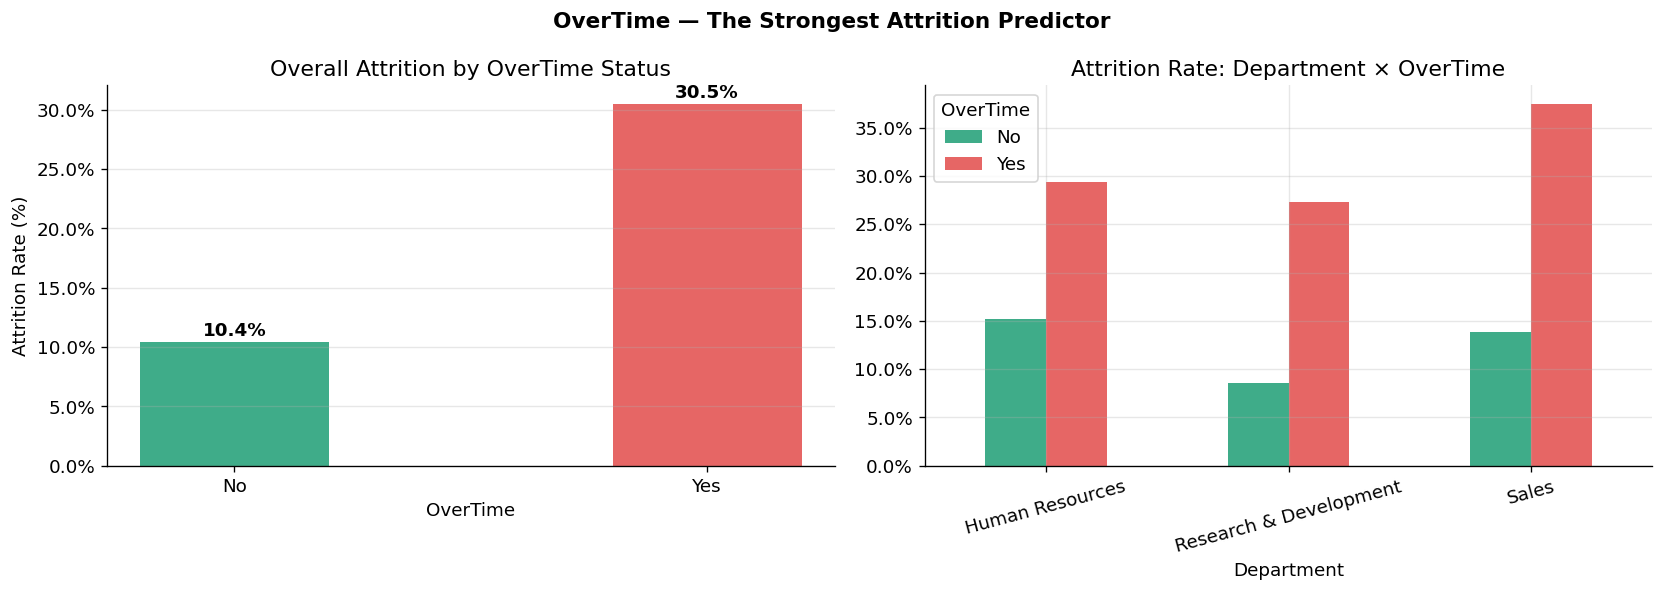

In [31]:
#Section 9 -- Overtime Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("OverTime — The Strongest Attrition Predictor",
             fontsize=13, fontweight="bold")

# Left: overall
axes[0].bar(
    ot_overall.index, ot_overall.values,
    color=["#1D9E75", "#E24B4A"], width=0.4, alpha=0.85
)
for i, (k, v) in enumerate(ot_overall.items()):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
axes[0].set_title("Overall Attrition by OverTime Status")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xlabel("OverTime")
axes[0].set_ylabel("Attrition Rate (%)")

# Right: by department
ot_dept.T.plot(kind="bar", ax=axes[1],
               color=["#1D9E75", "#E24B4A"], alpha=0.85)
axes[1].set_title("Attrition Rate: Department × OverTime")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xlabel("Department")
axes[1].legend(title="OverTime")
plt.xticks(rotation=15)

plt.tight_layout()
save(fig, "08_overtime_analysis.png")
plt.show()


In [32]:
# Week 1 -- Key Insights Summary
attrition_rate = (df["Attrition"] == "Yes").mean() * 100
ot_yes  = df[df["OverTime"] == "Yes"]["Attrition"].apply(lambda x: 1 if x=="Yes" else 0).mean() * 100
ot_no   = df[df["OverTime"] == "No"]["Attrition"].apply(lambda x: 1 if x=="Yes" else 0).mean() * 100
inc_yes = df[df["Attrition"] == "Yes"]["MonthlyIncome"].mean()
inc_no  = df[df["Attrition"] == "No"]["MonthlyIncome"].mean()
age_yes = df[df["Attrition"] == "Yes"]["Age"].mean()
age_no  = df[df["Attrition"] == "No"]["Age"].mean()

print("=" * 55)
print("  WEEK 1 KEY INSIGHTS")
print("=" * 55)
print(f"""
  Dataset  : {df.shape[0]:,} employees · {df.shape[1]} features
  Attrition: {attrition_rate:.1f}% overall  (industry benchmark ~15%)

  FINDING 1 — OverTime is the biggest driver
    With overtime  : {ot_yes:.1f}% attrition
    Without overtime: {ot_no:.1f}% attrition
    → {ot_yes / ot_no:.1f}× the risk. Strongest actionable signal for HR.

  FINDING 2 — Pay gap between leavers and stayers
    Left company   : ${inc_yes:,.0f} / month avg
    Stayed         : ${inc_no:,.0f} / month avg
    → Leavers earned ${inc_no - inc_yes:,.0f}/month LESS.

  FINDING 3 — Youth flight risk
    Avg age (left)  : {age_yes:.1f} years
    Avg age (stayed): {age_no:.1f} years
    → Younger employees need stronger career growth paths.

  FINDING 4 — Sales has highest attrition by department
    → Needs targeted retention programs.

  FINDING 5 — Top ML features (from correlation)
    OverTime · JobSatisfaction · MonthlyIncome
    TotalWorkingYears · Age · StockOptionLevel
    → These will dominate the XGBoost model in Week 3.

  ─────────────────────────────────────────────────
  Figures saved to: {FIGURES_DIR}
    01_attrition_distribution.png
    02_numeric_distributions.png
    03_categorical_distributions.png
    04_attrition_by_category.png
    05_numeric_vs_attrition.png
    06_boxplots_income_age.png
    07_correlation_heatmap.png
    08_overtime_analysis.png
  ─────────────────────────────────────────────────

  Next → Week 2: Plotly dashboard + feature engineering
""")
print("=" * 55)
print("  ✅  Week 1 EDA Complete!")
print("=" * 55)

  WEEK 1 KEY INSIGHTS

  Dataset  : 1,470 employees · 31 features
  Attrition: 16.1% overall  (industry benchmark ~15%)

  FINDING 1 — OverTime is the biggest driver
    With overtime  : 30.5% attrition
    Without overtime: 10.4% attrition
    → 2.9× the risk. Strongest actionable signal for HR.

  FINDING 2 — Pay gap between leavers and stayers
    Left company   : $4,787 / month avg
    Stayed         : $6,833 / month avg
    → Leavers earned $2,046/month LESS.

  FINDING 3 — Youth flight risk
    Avg age (left)  : 33.6 years
    Avg age (stayed): 37.6 years
    → Younger employees need stronger career growth paths.

  FINDING 4 — Sales has highest attrition by department
    → Needs targeted retention programs.

  FINDING 5 — Top ML features (from correlation)
    OverTime · JobSatisfaction · MonthlyIncome
    TotalWorkingYears · Age · StockOptionLevel
    → These will dominate the XGBoost model in Week 3.

  ─────────────────────────────────────────────────
  Figures saved to: d:\